## Objective functions of the thesis "Determination of Optimal Number of Crews for Pipe Replacement Works Using Optimisation Algorithms"

In [412]:
# Import libraries
import wntr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [413]:
# Import the water network model
ds_sel = 'DS2' # which damage scenario to analyse
inp_file = "BBM-EPS_"+ds_sel+"mcg.inp"
#inp_file = "BBM-EPS_"+ds_sel+"_restoration.inp"
wn = wntr.network.WaterNetworkModel(inp_file)

In [414]:
# Simulation settings
wn.options.time.duration = 7 * 24 * 3600       # 7 days
wn.options.time.hydraulic_timestep = 15*60     # 15 minutes
wn.options.time.report_timestep = 15*60        # 15 minutes

# Start simulation at 07:00 AM
wn.options.time.start_clocktime = 7 * 3600

# Pressure Driven Analysis
wn.options.hydraulic.demand_model = "PDA"
wn.options.hydraulic.required_pressure = 20
wn.options.hydraulic.minimum_pressure = 0
wn.options.hydraulic.pressure_exponent = 0.5

In [415]:
# timestep
dt = wn.options.time.hydraulic_timestep

# timestep in minutes
dtm = dt/60

In [416]:
# run the simulation
sim = wntr.sim.EpanetSimulator(wn)
results = sim.run_sim()

In [417]:
# getting the actual demand at each node over time 
demand = results.node["demand"]*1000  # convert to L/s

In [418]:
# Find all demand nodes (base demand > 0)
demand_nodes = []

# Expected demand at each node
#expected = {}

for node_name in wn.junction_name_list:

    node = wn.get_node(node_name)

    if node.base_demand > 0:

        demand_nodes.append(node_name)

print(f"Demand nodes found: {len(demand_nodes)}")

Demand nodes found: 4201


In [419]:
# Expected demand
expected = wntr.metrics.expected_demand(wn)

expected *= 1000        # convert to L/s

expected = expected[demand_nodes]

expected.index = demand.index


In [420]:
# Calculate the supply ratio at each time step
supply_ratio = demand[demand_nodes] / expected

# Clip the supply ratio to be between 0 and 1
supply_ratio = supply_ratio.clip(lower=0, upper=1)

In [421]:
# Finding emitter nodes (nodes starting with "E_")
emitter_nodes = [
    j for j in wn.junction_name_list
    if j.startswith("E_")
]

# Demand at emitter nodes (leakage) over time
leakage = demand[emitter_nodes]

### Functionality 
The percentage of the demand supplied by the distribution system.

In [422]:
def system_functionality(demand, demand_nodes, expected):

    # Total delivered demand at all demand nodes
    Qi_total = demand[demand_nodes].sum(axis=1)

    # Total expected demand
    DQi_total = expected.sum(axis=1)

    # Equation 7
    functionality = 100 * Qi_total / DQi_total

    # Keep functionality values below 100  
    functionality = functionality.clip(lower=0, upper=100)

    return functionality

In [423]:
functionality_series = system_functionality(demand, demand_nodes, expected)

print(functionality_series)

0         100.0
900       100.0
1800      100.0
2700      100.0
3600      100.0
          ...  
601200    100.0
602100    100.0
603000    100.0
603900    100.0
604800    100.0
Length: 673, dtype: float64


### 1. OF: Time without supply for hospital/firefighting (FH)
The time that the hospitals and the firefighting flows are without supply It's calculated by multiplying the simulation time step duration  with the number of time steps in which the supply/demand ratio for the hospitals and firefighting flows was less than 0.5.

In [424]:
def OF_FH(supply_ratio, dtm, ratio=0.5):

    hospital_nodes = ["32941", "43816"]

    fire_nodes = ["54537", "21641"]

    # Critical nodes (hospitals and fire stations)
    critical_nodes = hospital_nodes + fire_nodes

    FH_undersupplied = supply_ratio[critical_nodes] <= ratio

    FH_value = FH_undersupplied.sum().sum() * dtm

    return FH_value, FH_undersupplied

In [425]:
FH_value, FH_undersupplied = OF_FH(supply_ratio, dtm)

#FH_undersupplied.to_excel("FH_undersupplied.xlsx", index=False)

print(f"FH = {FH_value:,.2f} minutes") 

FH = 2,160.00 minutes


### 2. rapidity of recovery (t95)
The time that the hospitals and the firefighting flows are without supply It's calculated by multiplying the simulation time step duration  with the number of time steps in which the supply/demand ratio for the hospitals and firefighting flows was less than 0.5.

In [426]:
def OF_t95(demand, demand_nodes, expected, dtm, threshold=95, stability_hours=24):

    # System functionality
    Qi_total = demand[demand_nodes].sum(axis=1)
    DQi_total = expected.sum(axis=1)

    functionality = 100 * Qi_total / DQi_total
    functionality = functionality.clip(lower=0, upper=100)

    values = functionality.to_numpy()
    times = functionality.index.to_numpy()

    # Number of timesteps corresponding to the stability period
    stability_steps = int((stability_hours * 60) / dtm)

    # Search only where a full stability window still fits
    for i in range(len(values) - stability_steps + 1):

        if (
            values[i] >= threshold
            and np.all(values[i:i + stability_steps] >= threshold)
        ):
            return times[i] / 60      # minutes

    return np.nan

In [427]:
t95 = OF_t95(demand, demand_nodes, expected, dtm)

print(f"Rapidity of recovery (t95): {t95:.2f} minutes")

Rapidity of recovery (t95): nan minutes


### 3. OF: Resilience loss (RL)
RL considers the Accumulated loss of functionality during the recovery process of the system. It represents the area between the full functionality line (100%) and the functionality time series

In [428]:
def OF_RL(demand, demand_nodes, expected, dtm):

    # Total demand at all demand nodes over time
    Qi_total = demand[demand_nodes].sum(axis=1)

    # Total expected demand (base demand) at all demand nodes
    DQi_total = expected.sum(axis=1)

    # Formula to calculate functionality
    functionality = 100 * Qi_total / DQi_total

    functionality = functionality.clip(lower=0, upper=100)


    loss = 100 - functionality

    resilience_loss = loss.sum() * dtm

    return resilience_loss

In [429]:
RL = OF_RL(demand, demand_nodes, expected, dtm)

print(f"Resilience Loss = {RL:,.2f} %-minutes")

Resilience Loss = 50,014.00 %-minutes


### 4. OF: Average time of no user service (Time no serv.)
Measures the average time each demand node across the network stayed without service. The formula of this objective is similar to the FH formula, but it considers the sum of all demand nodes that were undersupplied (supply/demand ratio under 0.5) divided by the total amount of demand nodes (DN)

In [430]:
def OF_time_no_serv(supply_ratio, dtm, ratio=0.5):

    undersupplied = supply_ratio <= ratio

    #Number of demand nodes
    DN = supply_ratio.shape[1]

    time_no_service = undersupplied.sum().sum() * dtm / DN

    return time_no_service

In [431]:
time_no_serv = OF_time_no_serv(supply_ratio, dtm)

print(f"Average Time of No User Service = {time_no_serv:.2f} minutes")

Average Time of No User Service = 87.21 minutes


### 5. OF: Number of users without service for eight consecutive hours (NWSECH)
Number of demand nodes that stayed without service for more than eight consecutive hours. It’s calculated by counting the amount of nodes with at least one continuous 8-hour period during which the node's supply/demand ratio never exceeds 0.5.

In [432]:
def OF_NWSECH(supply_ratio, dtm, ratio=0.5, hours=8):

    undersupplied = supply_ratio <= ratio

    # Number of required steps based on an 8-hour period and the hydraulic timestep defined in the water network model.
    threshold_steps = int((hours * 60) / dtm)

    # list to store nodes that have no service for 8 consecutive hours
    nodes_no_service = 0


    for node in undersupplied.columns:

        consecutive = 0
        max_consecutive = 0

        for value in undersupplied[node]:

            if value:
                consecutive += 1
                max_consecutive = max(max_consecutive, consecutive)
            else:
                consecutive = 0

        if max_consecutive >= threshold_steps:
            nodes_no_service += 1

    return nodes_no_service

In [433]:
NNS = OF_NWSECH(supply_ratio, dtm)

print(f"Nodes without service for 8 consecutive hours = {NNS}")

Nodes without service for 8 consecutive hours = 5


### 6. OF: Water loss (WL)
counts the volume in litres of water lost during the period after the earthquake, by multiplying the time step with the sum of the outflows across all damages in the system.

In [434]:
def OF_WL(demand, emitter_nodes, dt):


    leakage = demand[emitter_nodes]

    water_loss = leakage.sum().sum() * dt / 1000

    return water_loss

In [435]:
WL = OF_WL(demand, emitter_nodes, dt)

print(f"Water loss = {WL:,.2f} m³")

Water loss = 175,754.95 m³


## Graphical representations of the objective functions

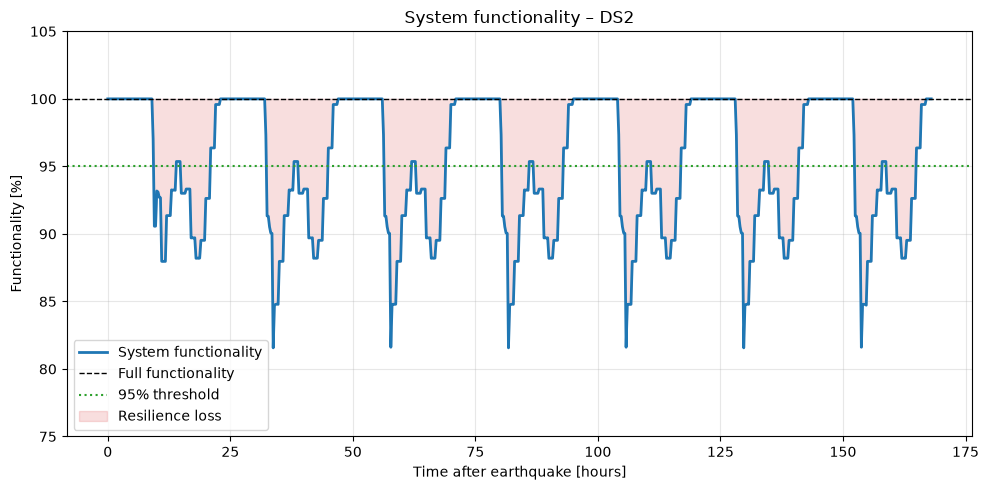

In [436]:
# Plot functionality over the simulation period
time_hours = functionality_series.index.to_numpy() / 3600

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(time_hours, functionality_series.to_numpy(), color="tab:blue", linewidth=2,
        label="System functionality")
ax.axhline(100, color="black", linestyle="--", linewidth=1, label="Full functionality")
ax.axhline(95, color="tab:green", linestyle=":", linewidth=1.5, label="95% threshold")

# Shade the resilience loss: the area between actual and full functionality.
ax.fill_between(time_hours, functionality_series.to_numpy(), 100,
                color="tab:red", alpha=0.15, label="Resilience loss")

# t95 is stored in seconds; show it only if 95% functionality is reached permanently.
if np.isfinite(t95):
    t95_hours = t95 / 60
    ax.axvline(t95_hours, color="tab:green", linestyle="--", linewidth=1.5)
    ax.annotate(f"t95 = {t95_hours:.1f} h", xy=(t95_hours, 95),
                xytext=(6, 8), textcoords="offset points", color="tab:green")

ax.set(title=f"System functionality – {ds_sel}", xlabel="Time after earthquake [hours]",
       ylabel="Functionality [%]", ylim=(75, 105))
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
fig.tight_layout()
plt.show()

# Optional: save a publication-quality copy.
# fig.savefig(f"functionality_{ds_sel}.png", dpi=300, bbox_inches="tight")